In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

process = Path("../Data/Processed")
figure = Path("../Reports/Figure")

rfm_df = pd.read_csv(process / "retail_sales_rfm.csv")


In [6]:
rfm_df.head(10)

,CustomerID,PrimaryCountry,FirstPurchaseDate,LastPurchaseDate,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,CustomerLifetimeDays,RecencyScore,FrequencyScore,MonetaryScore,RFMScore
0,12346,United Kingdom,2009-12-14 08:34:00,2011-01-18 10:01:00,326,12,77556.46,74285,6463.04,400,2,5,5,255
1,12347,Iceland,2010-10-31 14:20:00,2011-12-07 15:52:00,3,8,4921.53,2967,615.19,402,5,4,5,545
2,12348,Finland,2010-09-27 14:59:00,2011-09-25 13:13:00,76,5,2019.40,2714,403.88,363,3,4,4,344
3,12349,Italy,2010-04-29 13:20:00,2011-11-21 09:51:00,19,4,4428.69,1624,1107.17,571,5,3,5,535
4,12350,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,311,1,334.40,197,334.40,0,2,1,2,212
5,12351,Unspecified,2010-11-29 15:23:00,2010-11-29 15:23:00,376,1,300.93,261,300.93,0,2,1,2,212
6,12352,Norway,2010-11-12 10:20:00,2011-11-03 14:37:00,37,10,2849.84,724,284.98,356,4,5,4,454
7,12353,Bahrain,2010-10-27 12:44:00,2011-05-19 17:47:00,205,2,406.76,212,203.38,204,2,2,2,222
8,12354,Spain,2011-04-21 13:11:00,2011-04-21 13:11:00,233,1,1079.40,530,1079.40,0,2,1,3,213
9,12355,Bahrain,2010-05-21 11:59:00,2011-05-09 13:49:00,215,2,947.61,543,473.80,353,2,2,3,223


In [15]:
sales_df = pd.read_csv(process / "retail_sales_cleaned.csv",dtype={"Invoice": "string","StockCode": "string"},parse_dates=["InvoiceDate"])

print("Cleaned sales shape:", sales_df.shape)

unique_products_df = (sales_df.groupby("CustomerID", as_index=False).agg(UniqueProducts=("StockCode", "nunique")))

unique_products_df.shape

Cleaned sales shape: (779425, 10)


(5878, 2)

In [16]:
segm_df = rfm_df.merge(unique_products_df,on="CustomerID",how="left")

print("Merged shape:", segm_df.shape)

Merged shape: (5878, 15)


In [17]:
segm_df.drop(columns=["FirstPurchaseDate","LastPurchaseDate"], inplace=True)

In [20]:
segm_df["AvgQty"] = (segm_df["TotalQuantity"] / segm_df["Frequency"]).round(2)

In [ ]:
features = ["Recency","Frequency","Monetary","AverageOrderValue","CustomerLifetimeDays","UniqueProducts","AvgQty"]

X = segm_df[features].copy()

print("Selected segmentation features:")
print(features)
print("\nFeature shape:", X.shape)

X.head()

Selected segmentation features:
['Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'CustomerLifetimeDays', 'UniqueProducts', 'AvgQty']

Feature shape: (5878, 7)


,Recency,Frequency,Monetary,AverageOrderValue,CustomerLifetimeDays,UniqueProducts,AvgQty
0,326,12,77556.46,6463.04,400,27,6190.42
1,3,8,4921.53,615.19,402,126,370.88
2,76,5,2019.40,403.88,363,25,542.80
3,19,4,4428.69,1107.17,571,138,406.00
4,311,1,334.40,334.40,0,17,197.00


In [25]:
print("Missing values:")
print(X.isnull().sum())

print("\nSummary statistics:")
display(X.describe())

print("\nSkewness:")
print(X.skew().sort_values(ascending=False))

Missing values:
Recency                 0
Frequency               0
Monetary                0
AverageOrderValue       0
CustomerLifetimeDays    0
UniqueProducts          0
AvgQty                  0
dtype: int64

Summary statistics:


,Recency,Frequency,Monetary,AverageOrderValue,CustomerLifetimeDays,UniqueProducts,AvgQty
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,201.866791,6.289384,2955.904095,385.180854,273.393671,81.989112,247.556827
std,209.353961,13.009406,14440.852688,1214.286454,258.964160,116.484552,1424.480949
min,1.000000,1.000000,2.950000,2.950000,0.000000,1.000000,1.000000
25%,26.000000,1.000000,342.280000,176.682500,0.000000,19.000000,91.000000
50%,96.000000,3.000000,867.740000,279.240000,221.000000,45.000000,153.585000
75%,380.000000,7.000000,2248.305000,414.900000,512.000000,103.000000,256.925000
max,739.000000,398.000000,580987.040000,84236.250000,738.000000,2550.000000,87167.000000



Skewness:
AverageOrderValue       57.132568
AvgQty                  47.907132
Monetary                25.070190
Frequency               12.639951
UniqueProducts           6.224360
Recency                  0.887194
CustomerLifetimeDays     0.387952
dtype: float64


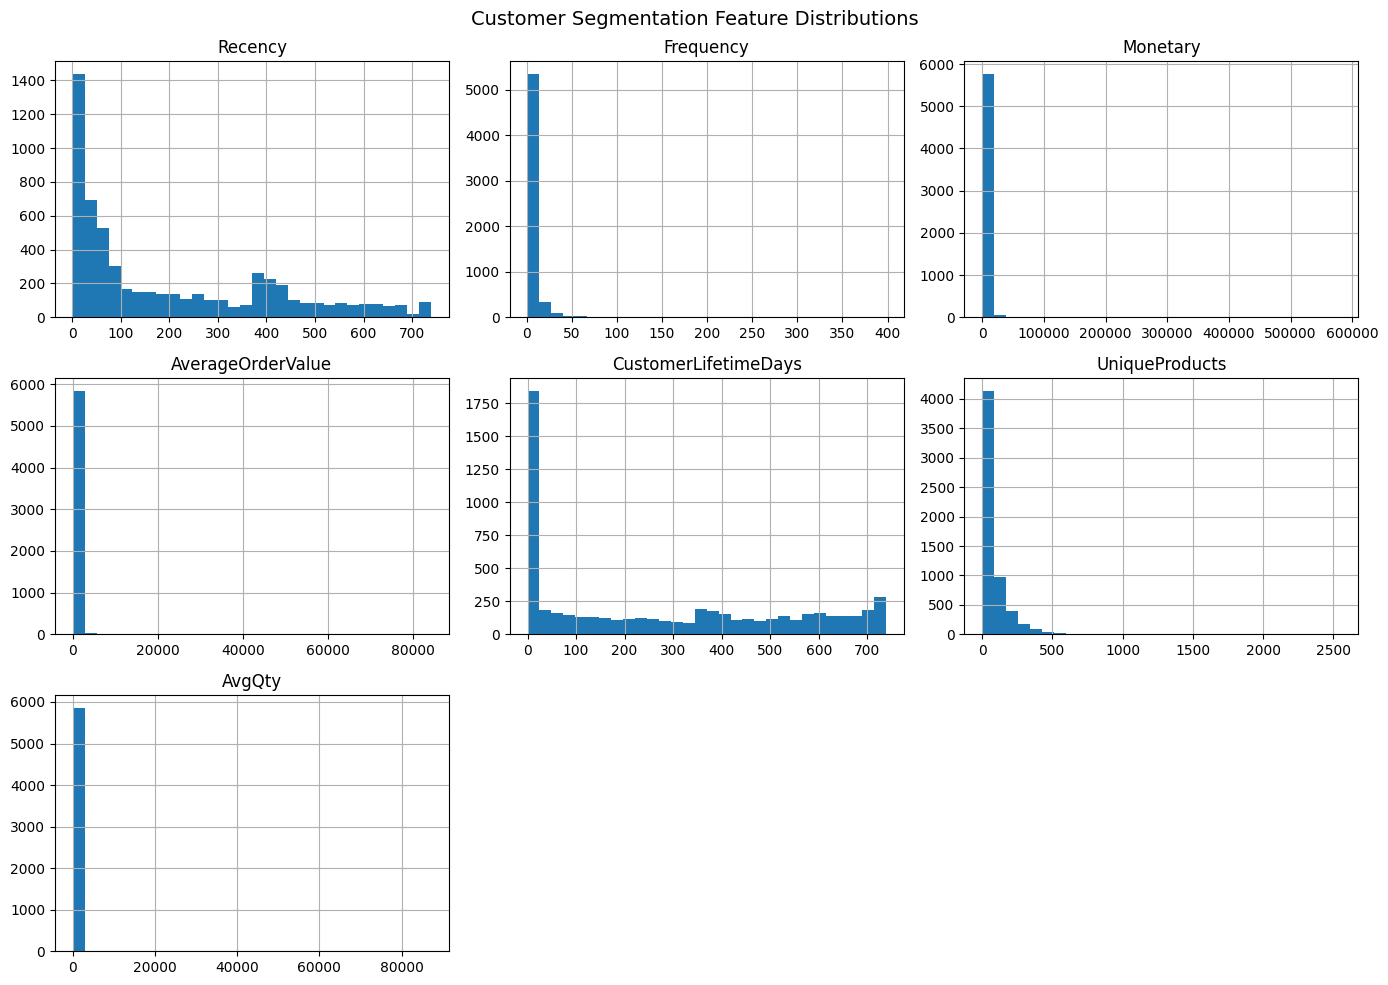

In [31]:
X.hist(bins=30,figsize=(14, 10))
plt.suptitle("Customer Segmentation Feature Distributions",fontsize=14)
plt.tight_layout()
plt.savefig("../Reports/Figure/3-Customer_Segmentation.png",
    dpi=300,
)
plt.show()

In [32]:
# Log transformation reduces the effect of extreme values
X_log = np.log1p(X)
display(X_log.head())

# K-Means uses distance calculations, so all features must be on a comparable scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

print("Scaling completed.\n scaled shape:", X_scaled.shape)

,Recency,Frequency,Monetary,AverageOrderValue,CustomerLifetimeDays,UniqueProducts,AvgQty
0,5.789960,2.564949,11.258774,8.774010,5.993961,3.332205,8.730920
1,1.386294,2.197225,8.501578,6.423555,5.998937,4.844187,5.918571
2,4.343805,1.791759,7.611051,6.003591,5.897154,3.258097,6.298582
3,2.995732,1.609438,8.396085,7.010465,6.349139,4.934474,6.008813
4,5.743003,0.693147,5.815324,5.815324,0.000000,2.890372,5.288267


Scaling completed.
 scaled shape: (5878, 7)


In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)
inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=20)
    labels = kmeans.fit_predict(X_scaled)

    # A score that tells you how [tight] your groups are
    inertia_values.append(kmeans.inertia_)

    # A score that tells you how [separated] your groups are
    silhouette_values.append(silhouette_score(X_scaled,labels))


kmeans_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "SilhouetteScore": silhouette_values
    })

kmeans_evaluation

,K,Inertia,SilhouetteScore
0,2,25287.673536,0.336040
1,3,20851.678416,0.255587
2,4,17422.178509,0.260248
3,5,15564.780122,0.245306
4,6,14236.108296,0.232689
5,7,13222.915276,0.221987
6,8,12371.186215,0.216794


Best k = 4 because 2 cluster is low also see it contain high sil. = 0.336 but i don't use it

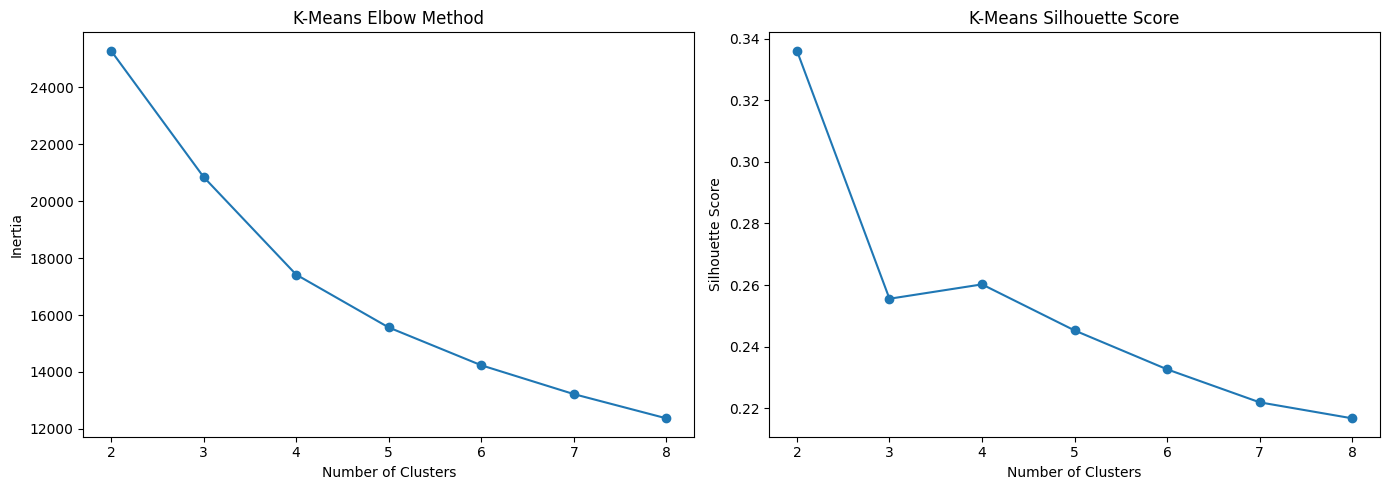

In [43]:
fig,axes = plt.subplots(1,2,figsize=(14,5))

axes[0].plot(kmeans_evaluation["K"],kmeans_evaluation["Inertia"],marker="o")
axes[0].set_title("K-Means Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(kmeans_evaluation["K"])

axes[1].plot(kmeans_evaluation["K"],kmeans_evaluation["SilhouetteScore"],marker="o")
axes[1].set_title("K-Means Silhouette Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(kmeans_evaluation["K"])

plt.tight_layout()
plt.savefig("../Reports/Figure/3-KMeans_Evaluation.png",dpi=300,bbox_inches="tight")
plt.show()

In [45]:
kmeans_2 = KMeans(n_clusters=2,random_state=42,n_init=20)
kmeans_4 = KMeans(n_clusters=4,random_state=42,n_init=20)

labels_k2 = kmeans_2.fit_predict(X_scaled)
segm_df["Cluster_K4"] = kmeans_4.fit_predict(X_scaled)

print("K=2 cluster distribution:")
print(pd.Series(labels_k2).value_counts().sort_index())

print("\nK=4 cluster distribution:")
print(segm_df["Cluster_K4"].value_counts().sort_index())

K=2 cluster distribution:
0    3226
1    2652
Name: count, dtype: int64

K=4 cluster distribution:
Cluster_K4
0    2348
1     966
2    1062
3    1502
Name: count, dtype: int64


In [ ]:
profile_columns = ["Recency","Frequency","Monetary","TotalQuantity","AverageOrderValue","CustomerLifetimeDays","UniqueProducts","AvgQty"]

cluster_profile = (segm_df.groupby("Cluster_K4")[profile_columns].mean().round(2))

cluster_profile["CustomerCount"] = segm_df["Cluster_K4"].value_counts().sort_index()

cluster_profile

,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,CustomerLifetimeDays,UniqueProducts,AvgQty,CustomerCount
Cluster_K4,,,,,,,,,
0,172.59,4.11,1088.33,641.50,286.58,318.57,60.31,168.83,2348
1,364.51,1.48,183.92,80.86,129.90,40.67,11.92,58.77,966
2,339.78,1.13,642.77,455.54,530.17,3.49,29.02,400.78,1062
3,45.51,16.44,9293.68,5623.04,600.99,543.29,198.39,383.70,1502


In [51]:
segment_map = {
    0:"💙 Loyal Customers",
    1:"😴 Inactive Customers",
    2:"⚠️ At Risk",
    3:"🏆 Champions"
}

segm_df["Segment_KMeans"] = segm_df["Cluster_K4"].map(segment_map)

segm_df.sample(10)

,CustomerID,PrimaryCountry,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,CustomerLifetimeDays,RecencyScore,FrequencyScore,MonetaryScore,RFMScore,UniqueProducts,AvgQty,Cluster_K4,Segment_KMeans
1028,13385,United Kingdom,330,1,534.57,281,534.57,0,2,1,2,212,35,281.00,2,⚠️ At Risk
5273,17680,United Kingdom,24,3,497.45,155,165.82,488,4,3,2,432,20,51.67,0,💙 Loyal Customers
3484,15864,United Kingdom,23,7,2180.76,1486,311.54,359,4,4,4,444,18,212.29,0,💙 Loyal Customers
4879,17276,United Kingdom,403,1,502.49,187,502.49,0,2,2,2,222,50,187.00,2,⚠️ At Risk
1009,13365,United Kingdom,34,2,2225.37,1247,1112.68,184,4,2,4,424,122,623.50,3,🏆 Champions
2023,14392,United Kingdom,433,1,266.40,114,266.40,0,1,1,1,111,14,114.00,2,⚠️ At Risk
3364,15742,United Kingdom,620,1,156.87,51,156.87,0,1,1,1,111,41,51.00,1,😴 Inactive Customers
3251,15629,United Kingdom,451,4,2240.90,1518,560.22,82,1,3,4,134,39,379.50,0,💙 Loyal Customers
5211,17614,United Kingdom,58,1,386.32,235,386.32,0,4,2,2,422,97,235.00,2,⚠️ At Risk
5786,18196,United Kingdom,96,4,1457.19,1038,364.30,537,3,4,4,344,210,259.50,0,💙 Loyal Customers


In [ ]:
segment_profile = (
    segm_df.groupby("Segment_KMeans")
    .agg(
        CustomerCount=("CustomerID","count"),
        AvgRecency=("Recency","mean"),
        AvgFrequency=("Frequency","mean"),
        AvgMonetary=("Monetary","mean"),
        AvgOrderValue=("AverageOrderValue","mean"),
        AvgLifetimeDays=("CustomerLifetimeDays","mean"),
        AvgUniqueProducts=("UniqueProducts","mean"),
        AvgQuantity=("AvgQty","mean")
    ).round(2)
)

print(segment_profile)

                      CustomerCount  AvgRecency  AvgFrequency  AvgMonetary  \
Segment_KMeans                                                               
⚠️ At Risk                     1062      339.78          1.13       642.77   
🏆 Champions                    1502       45.51         16.44      9293.68   
💙 Loyal Customers              2348      172.59          4.11      1088.33   
😴 Inactive Customers            966      364.51          1.48       183.92   

                      AvgOrderValue  AvgLifetimeDays  AvgUniqueProducts  \
Segment_KMeans                                                            
⚠️ At Risk                   530.17             3.49              29.02   
🏆 Champions                  600.99           543.29             198.39   
💙 Loyal Customers            286.58           318.57              60.31   
😴 Inactive Customers         129.90            40.67              11.92   

                      AvgQuantity  
Segment_KMeans                     
⚠️ At Ri

In [55]:
from sklearn.cluster import DBSCAN

# -1 = outlier customer
# 0,1,2... = detected customer groups

dbscan = DBSCAN(eps=0.8,min_samples=15)
segm_df["Segment_DBSCAN"] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster distribution:")
print(segm_df["Segment_DBSCAN"].value_counts().sort_index())

segm_df["IsDBSCANOutlier"] = segm_df["Segment_DBSCAN"] == -1

print("DBSCAN outliers:",segm_df["IsDBSCANOutlier"].sum())
print("Outlier percentage:",round(segm_df["IsDBSCANOutlier"].mean()*100,2),"%")

DBSCAN cluster distribution:
Segment_DBSCAN
-1     678
 0    5200
Name: count, dtype: int64
DBSCAN outliers: 678
Outlier percentage: 11.53 %


In [56]:
segm_df.head(10)

,CustomerID,PrimaryCountry,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,CustomerLifetimeDays,RecencyScore,FrequencyScore,MonetaryScore,RFMScore,UniqueProducts,AvgQty,Cluster_K4,Segment_KMeans,Segment_DBSCAN,IsDBSCANOutlier
0,12346,United Kingdom,326,12,77556.46,74285,6463.04,400,2,5,5,255,27,6190.42,3,🏆 Champions,-1,True
1,12347,Iceland,3,8,4921.53,2967,615.19,402,5,4,5,545,126,370.88,3,🏆 Champions,0,False
2,12348,Finland,76,5,2019.40,2714,403.88,363,3,4,4,344,25,542.80,0,💙 Loyal Customers,0,False
3,12349,Italy,19,4,4428.69,1624,1107.17,571,5,3,5,535,138,406.00,3,🏆 Champions,0,False
4,12350,Norway,311,1,334.40,197,334.40,0,2,1,2,212,17,197.00,2,⚠️ At Risk,0,False
5,12351,Unspecified,376,1,300.93,261,300.93,0,2,1,2,212,21,261.00,2,⚠️ At Risk,0,False
6,12352,Norway,37,10,2849.84,724,284.98,356,4,5,4,454,70,72.40,0,💙 Loyal Customers,0,False
7,12353,Bahrain,205,2,406.76,212,203.38,204,2,2,2,222,23,106.00,0,💙 Loyal Customers,0,False
8,12354,Spain,233,1,1079.40,530,1079.40,0,2,1,3,213,58,530.00,2,⚠️ At Risk,0,False
9,12355,Bahrain,215,2,947.61,543,473.80,353,2,2,3,223,35,271.50,0,💙 Loyal Customers,0,False


In [59]:
import joblib
model = Path("../Models/Segmentation/")

segm_df.to_csv(process / "retail_customer_segments.csv",index=False)

joblib.dump({
    "scaler":scaler,
    "kmeans":kmeans_4,
    "features":features,
    "segment_map":segment_map
},model / "customer_segmentation_pipeline.pkl")

print("Day 3 files saved successfully.")
print("Dataset shape:",segm_df.shape)
print("Saved dataset:",process / "retail_customer_segments.csv")
print("Saved model:",model / "customer_segmentation_pipeline.pkl")

Day 3 files saved successfully.
Dataset shape: (5878, 18)
Saved dataset: ..\Data\Processed\retail_customer_segments.csv
Saved model: ..\Models\Segmentation\customer_segmentation_pipeline.pkl
